In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



In [2]:
data_dir = Path(r"C:\Users\myles\OneDrive\Desktop\data2")

files = sorted(data_dir.glob("phi*"))
print("Number of files found:", len(files))
files


Number of files found: 5


[WindowsPath('C:/Users/myles/OneDrive/Desktop/data2/phi0.40_double_stiff.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data2/phi0.50_A.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data2/phi0.50_B.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data2/phi0.50_N200.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data2/phi0.50_N400.log')]

In [3]:
def find_table_start(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Time"):
                return i
    raise ValueError(f"No table header found in {path}")

# Find the end of the table by locating the line that begins with "Loop"
def find_table_end(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Loop"):
                return i
    return None  # If no end marker is found, return None


In [4]:
columns = []
column_names = []

for file in files:
    start = find_table_start(file)
    end = find_table_end(file)

    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=start,
        nrows=end - start if end is not None else None,
        on_bad_lines="skip",
        engine="python"
    )

    col = df.iloc[:, 4]  # 5th column

    # Force a unique name based on the filename
    source = Path(file).stem
    new_name = f"{source}_stress_xy"

    col = col.rename(new_name)

    columns.append(col)
    column_names.append(new_name)


new_df = pd.concat(columns, axis=1)
new_df.columns = column_names

new_df.insert(0, "Time", range(len(new_df)))

eta_f = 0.1 # fluid viscosity
gamma_dot = 0.01 # shear rate


# Want to calculate reduced viscosity for each stress column
for col in new_df.columns[1:]:
    reduced_col_name = f"reduced_{col}"
    new_df[reduced_col_name] = np.abs(new_df[col] / (eta_f * gamma_dot))
# Calculate reduced viscosity
new_df.head()

steady_df = new_df[(new_df["Time"] >= 200) & (new_df["Time"] <= 3000)]
reduced_cols = [col for col in new_df.columns if col.startswith("reduced_")]

avg_reduced_stress = steady_df[reduced_cols].mean()
#print("Average Reduced Viscosity in Steady State:")
#print(avg_reduced_stress)

std_reduced_stress = steady_df[reduced_cols].std()
n = len(steady_df)
sem_reduced_stress = std_reduced_stress / np.sqrt(n)

print("Average Reduced Viscosity in Steady State:")
print(avg_reduced_stress)

print("\nStandard Error of the Mean for Reduced Viscosity:")
print(sem_reduced_stress)

C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2786337357.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2786337357.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2786337357.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Average Reduced Viscosity in Steady State:
reduced_phi0.40_double_stiff_stress_xy    49.307957
reduced_phi0.50_A_stress_xy               60.665213
reduced_phi0.50_B_stress_xy               61.966126
reduced_phi0.50_N200_stress_xy            58.007316
reduced_phi0.50_N400_stress_xy            57.695920
dtype: float64

Standard Error of the Mean for Reduced Viscosity:
reduced_phi0.40_double_stiff_stress_xy    2.217142
reduced_phi0.50_A_stress_xy               0.453002
reduced_phi0.50_B_stress_xy               0.398717
reduced_phi0.50_N200_stress_xy            0.264331
reduced_phi0.50_N400_stress_xy            0.199605
dtype: float64


C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2786337357.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2786337357.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


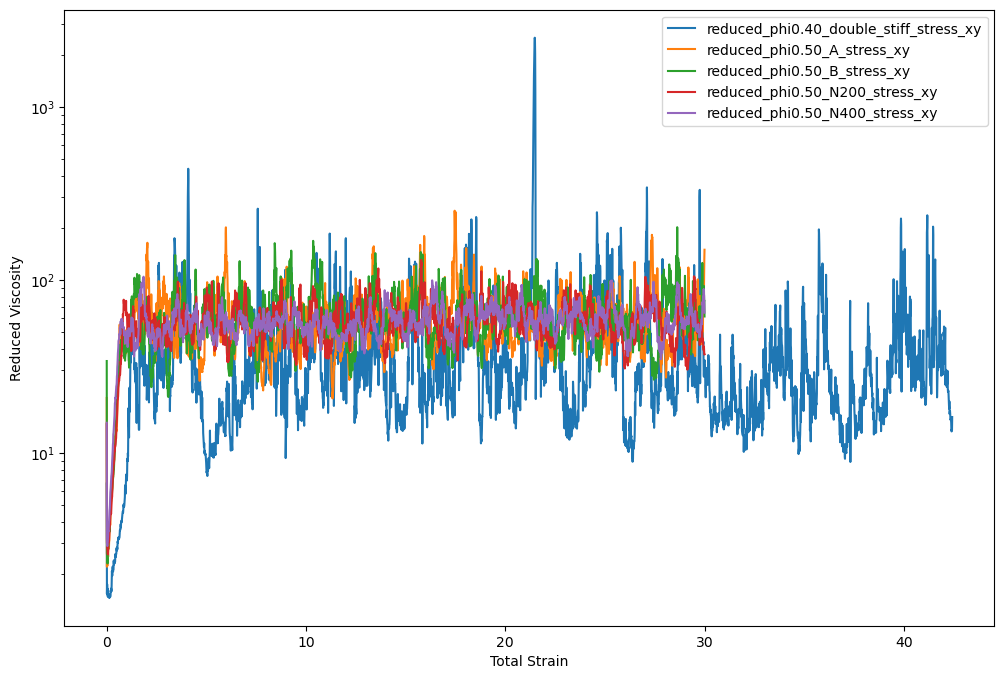

In [5]:
# I want to plot the reduced viscoisty agaisnt total strain, 3 seperate graphs, then one joint, which is gamma_dot * time for each column
new_df["Total_Strain"] = gamma_dot * new_df["Time"]
plt.figure(figsize=(12, 8))
for col in reduced_cols:
    plt.plot(new_df["Total_Strain"], new_df[col], label=col)
plt.xlabel("Total Strain")
plt.ylabel("Reduced Viscosity")

plt.legend()
plt.yscale("log")
plt.grid(False)
plt.show()




C:\Users\myles\AppData\Local\Temp\ipykernel_81664\3410735668.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axhline(y=avg_reduced_stress[1], color='red', linestyle='--', label=r'$\langle \eta_r \rangle  $, Seed A')  # Add average line for third column
C:\Users\myles\AppData\Local\Temp\ipykernel_81664\3410735668.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axhline(y=avg_reduced_stress[2], color='green', linestyle='--', label=r'$\langle \eta_r \rangle  $, Seed B')  # Add average line for fourth column


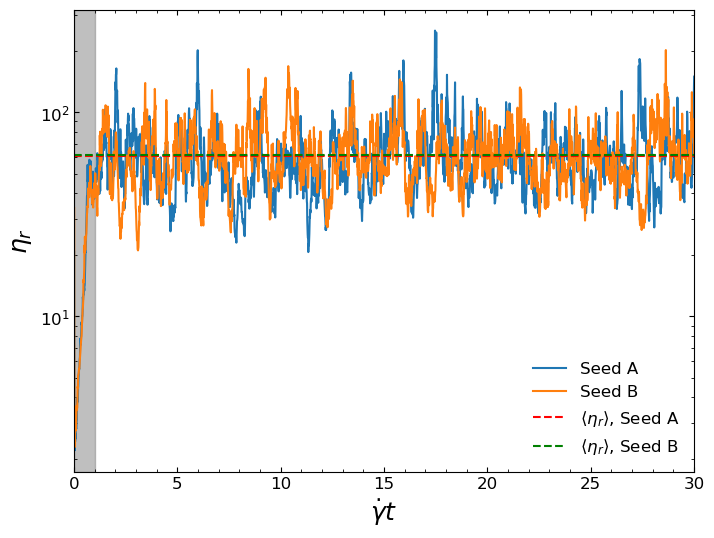

C:\Users\myles\AppData\Local\Temp\ipykernel_81664\3410735668.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axhline(y=avg_reduced_stress[3], color='red', linestyle='--', label=r'$\langle \eta_r \rangle  $, $N=200$')  # Add average line for third column
C:\Users\myles\AppData\Local\Temp\ipykernel_81664\3410735668.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axhline(y=avg_reduced_stress[4], color='green', linestyle='--', label=r'$\langle \eta_r \rangle  $, $N=400$')  # Add average line for fourth column


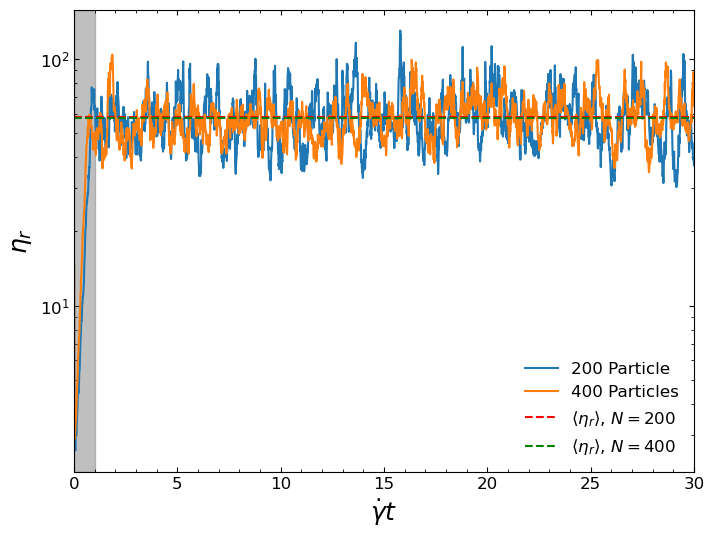

In [6]:
names_plot1 = ("Seed A", "Seed B")
names_plot2 = ("200 Particle", "400 Particles") 

plt.figure(figsize=(8, 6))
for col, name in zip(reduced_cols[1:3], names_plot1):  # zip pairs each col with a name
    plt.plot(new_df["Total_Strain"], new_df[col], label=name)


plt.axhline(y=avg_reduced_stress[1], color='red', linestyle='--', label=r'$\langle \eta_r \rangle  $, Seed A')  # Add average line for third column
plt.axhline(y=avg_reduced_stress[2], color='green', linestyle='--', label=r'$\langle \eta_r \rangle  $, Seed B')  # Add average line for fourth column


plt.axvspan(new_df["Total_Strain"].min(), 1, color='gray', alpha=0.50)
plt.xlim(0, 30)

plt.xlabel(r"$\dot\gamma t$", fontsize=18, weight='bold')
plt.ylabel(r"$\eta_r$", fontsize=18, weight='bold')
plt.yscale("log")
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=12)
#plt.xlim(5, 30)  
plt.legend(fontsize=12, frameon=False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)
plt.show()

plt.figure(figsize=(8, 6))
for col, name in zip(reduced_cols[3:], names_plot2):  # zip pairs each col with a name
    plt.plot(new_df["Total_Strain"], new_df[col], label=name)


plt.axhline(y=avg_reduced_stress[3], color='red', linestyle='--', label=r'$\langle \eta_r \rangle  $, $N=200$')  # Add average line for third column
plt.axhline(y=avg_reduced_stress[4], color='green', linestyle='--', label=r'$\langle \eta_r \rangle  $, $N=400$')  # Add average line for fourth column

plt.axvspan(new_df["Total_Strain"].min(), 1, color='gray', alpha=0.50)
plt.xlim(0, 30)

plt.xlabel(r"$\dot\gamma t$", fontsize=18, weight='bold')
plt.ylabel(r"$\eta_r$", fontsize=18, weight='bold')
plt.yscale("log")  # Set y-axis to logarithmic scale
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True, labelsize=12)
#plt.xlim(5, 30)
plt.legend(fontsize=12, frameon=False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)
plt.show()

C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2197124271.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].axhline(y=avg_reduced_stress[1], color='red', linestyle='--', label=r'$\langle \eta_r \rangle$ Seed A')
C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2197124271.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].axhline(y=avg_reduced_stress[2], color='green', linestyle='--', label=r'$\langle \eta_r \rangle$ Seed B')
C:\Users\myles\AppData\Local\Temp\ipykernel_81664\2197124271.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, intege

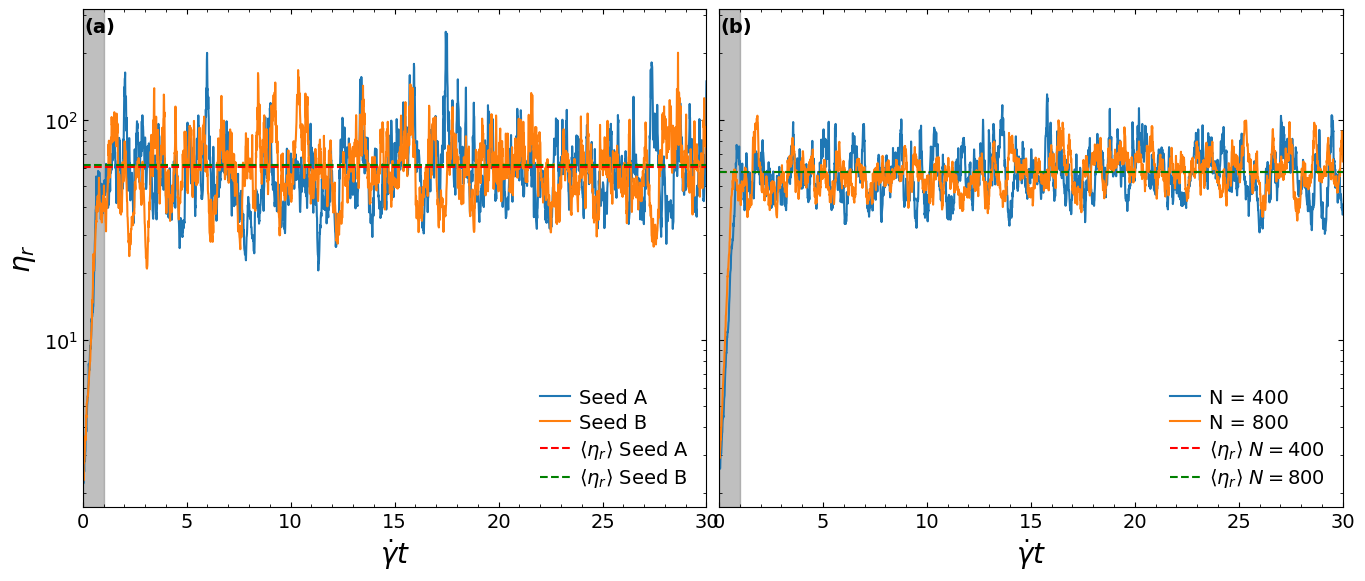

In [14]:
names_plot1 = ("Seed A", "Seed B")
names_plot2 = ("N = 400", "N = 800")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, constrained_layout=False)

# --- Plot 1 ---
for col, name in zip(reduced_cols[1:3], names_plot1):
    axes[0].plot(new_df["Total_Strain"], new_df[col], label=name)
axes[0].axhline(y=avg_reduced_stress[1], color='red', linestyle='--', label=r'$\langle \eta_r \rangle$ Seed A')
axes[0].axhline(y=avg_reduced_stress[2], color='green', linestyle='--', label=r'$\langle \eta_r \rangle$ Seed B')
axes[0].axvspan(new_df["Total_Strain"].min(), 1, color='gray', alpha=0.50)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel(r"$\dot\gamma t$", fontsize=20, weight='bold')
axes[0].set_ylabel(r"$\eta_r$", fontsize=20, weight='bold')
axes[0].set_yscale("log")
axes[0].minorticks_on()
axes[0].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=14)
axes[0].legend(fontsize=14, frameon=False, handlelength=1.5, handletextpad=0.5,
               labelspacing=0.3, borderpad=0.4)

# --- Plot 2 ---
for col, name in zip(reduced_cols[3:], names_plot2):
    axes[1].plot(new_df["Total_Strain"], new_df[col], label=name)
axes[1].axhline(y=avg_reduced_stress[3], color='red', linestyle='--', label=r'$\langle \eta_r \rangle$ $N=400$')
axes[1].axhline(y=avg_reduced_stress[4], color='green', linestyle='--', label=r'$\langle \eta_r \rangle$ $N=800$')
axes[1].axvspan(new_df["Total_Strain"].min(), 1, color='gray', alpha=0.50)
axes[1].set_xlim(0, 30)
axes[1].set_xlabel(r"$\dot\gamma t$", fontsize=20, weight='bold')
axes[1].set_yscale("log")
axes[1].minorticks_on()
axes[1].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=14)
axes[1].tick_params(axis='y', labelleft=False)
axes[1].legend(fontsize=14, frameon=False, handlelength=1.5, handletextpad=0.5,
               labelspacing=0.3, borderpad=0.4)

axes[0].text(9e-2, 2.5e2, '(a)', fontsize=14, fontweight='bold')
axes[1].text(90e-3, 2.5e2, '(b)', fontsize=14, fontweight='bold')

fig.subplots_adjust(left=0.08, right=0.98, top=0.95, bottom=0.12, wspace=0.02)
plt.savefig("tests.png", dpi=1200, bbox_inches="tight")
plt.show()